## Setup of Experiment
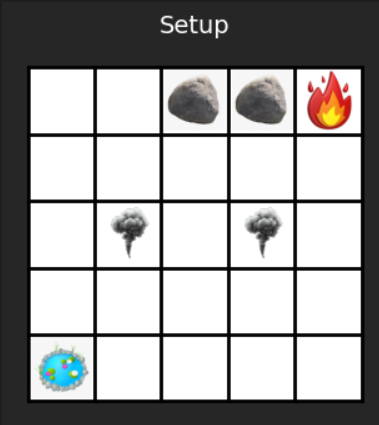

In [2]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import agent_related.agent_n_model as agent_module
import plot_related.transition_n_reward_matrices as trans_reward
import plot_related.value_fuction_visuvalizer as val_viz
import plot_related.optimal_policy_visuvalizer as policy_viz

importlib.reload(agent_module)
importlib.reload(trans_reward)
importlib.reload(val_viz)
importlib.reload(policy_viz)

from agent_related.agent_n_model import Agent
from plot_related.transition_n_reward_matrices import visualize_transition_and_reward
from plot_related.value_fuction_visuvalizer import visualize_value_function
from plot_related.optimal_policy_visuvalizer import visualize_optimal_policy

### Desiging MDP and visualize transition and reward matrices for starting from (3,3) [3M]

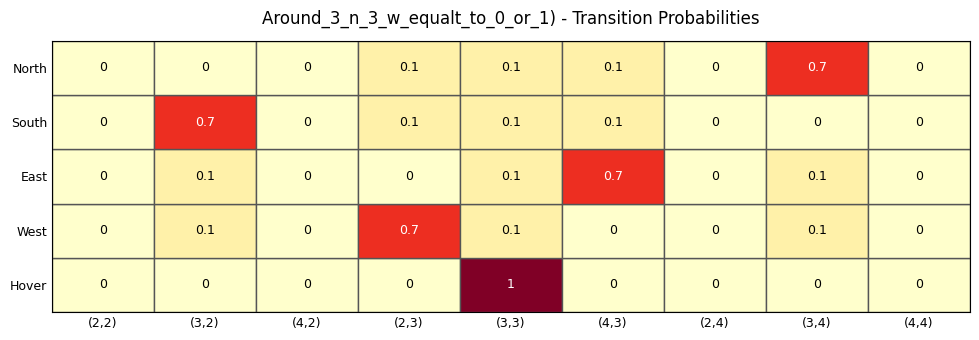

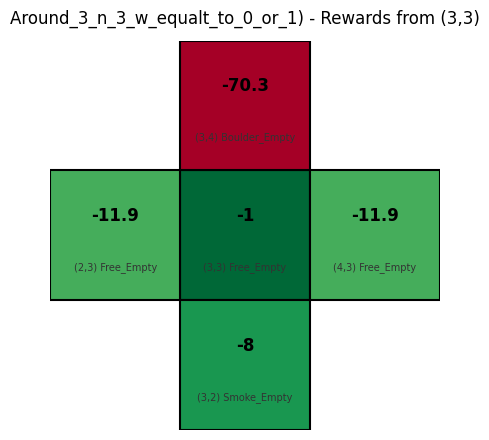

In [3]:
lake = (0, 0)
fire = (4, 4)
smoke_cells = {(1, 2), (3, 2)}
boulder_cells = {(2, 4), (3, 4)}
perp_actions = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}
n_states = 50
n_actions = 5
S1 = [""] * n_states
A1 = [(0, 1), (0, -1), (1, 0), (-1, 0), (0, 0)]
P1 = np.zeros((n_actions, n_states, n_states))
R1 = np.zeros((n_states, n_actions))
gamma1 = 0.95
max_iter1 = 1000

# State list S
for w in range(2):
    for y in range(5):
        for x in range(5):
            idx = x + 5 * y + 25 * w
            pos = (x, y)
            if pos == lake:       label = "Lake"
            elif pos == fire:     label = "Fire"
            elif pos in smoke_cells:   label = "Smoke"
            elif pos in boulder_cells: label = "Boulder"
            else:                 label = "Free"
            S1[idx] = f"{label}_{'Water' if w else 'Empty'}"

# Prob matrix (P)
for w in range(2):
    for y in range(5):
        for x in range(5):
            s = x + 5 * y + 25 * w
            if (x, y) in boulder_cells or ((x, y) == fire and w == 1):
                P1[:, s, s] = 1.0
                continue

            is_smoke = (x, y) in smoke_cells
            for a in range(n_actions):
                if a == 4: #Hovering
                    nw = 1 if (x, y) == lake and w == 0 else w
                    P1[a, s, x + 5 * y + 25 * nw] = 1.0
                    continue
                if is_smoke:
                    p_fwd, p_perp, p_stay = 0.4, 0.1, 0.4
                else:
                    p_fwd, p_perp, p_stay = 0.7, 0.1, 0.1

                dx, dy = A1[a]
                outcomes = [(dx, dy, p_fwd), (0, 0, p_stay)]
                for pa in perp_actions[a]:
                    pdx, pdy = A1[pa]
                    outcomes.append((pdx, pdy, p_perp))

                for mdx, mdy, prob in outcomes:
                    nx, ny = x + mdx, y + mdy
                    if not (0 <= nx < 5 and 0 <= ny < 5):
                        nx, ny = x, y  # off-grid: stay
                    nw = 1 if (nx, ny) == lake and w == 0 else w
                    P1[a, s, nx + 5 * ny + 25 * nw] += prob

# Reward Matrix (R)
for w in range(2):
    for y in range(5):
        for x in range(5):
            s = x + 5 * y + 25 * w
            if (x, y) in boulder_cells:
                for a in range(n_actions):
                    R1[s,a] = 0
                continue
            elif ((x, y) == fire and w == 1):
                for a in range(n_actions):
                    R1[s,a] = 0
                continue

            is_smoke = (x, y) in smoke_cells
            for a in range(n_actions):
                if a == 4: # hover: deterministic stay
                    R1[s, a] = -11.0 if is_smoke else -1.0
                    continue

                if is_smoke:
                    p_fwd, p_perp, p_stay = 0.4, 0.1, 0.4
                else:
                    p_fwd, p_perp, p_stay = 0.7, 0.1, 0.1

                dx, dy = A1[a]
                outcomes = [(dx, dy, p_fwd), (0, 0, p_stay)]
                for pa in perp_actions[a]:
                    pdx, pdy = A1[pa]
                    outcomes.append((pdx, pdy, p_perp))

                er = 0.0
                for mdx, mdy, prob in outcomes:
                    nx, ny = x + mdx, y + mdy
                    if not (0 <= nx < 5 and 0 <= ny < 5):
                        nx, ny = x, y
                    if (nx, ny) in boulder_cells:
                        er += prob * (-100.0)
                    elif (nx, ny) == fire and w == 1:
                        er += prob * 100.0
                    elif (nx, ny) in smoke_cells:
                        er += prob * (-11.0)
                    else:
                        er += prob * (-1.0)
                R1[s, a] = er

agent1 = Agent(S1, A1, P1, R1, gamma1)

# visualize transition and reward matrices for starting from (3,3)
fig_1_1,fig_1_2 = visualize_transition_and_reward(3,3,0,P1,R1,S1,"Around_3_n_3_w_equalt_to_0_or_1)")
# Indepent of water = 0/1 the plots are same

### Run value iteration Visualize the optimal value function and the corresponding policy [5M]

Number of iter =  175


c:\Users\gurra\OneDrive\Desktop\1Acads\sem-6\DA6400-RL\EE23B085_da6400_rl_master_repo\plot_related\value_fuction_visuvalizer.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 0.95])


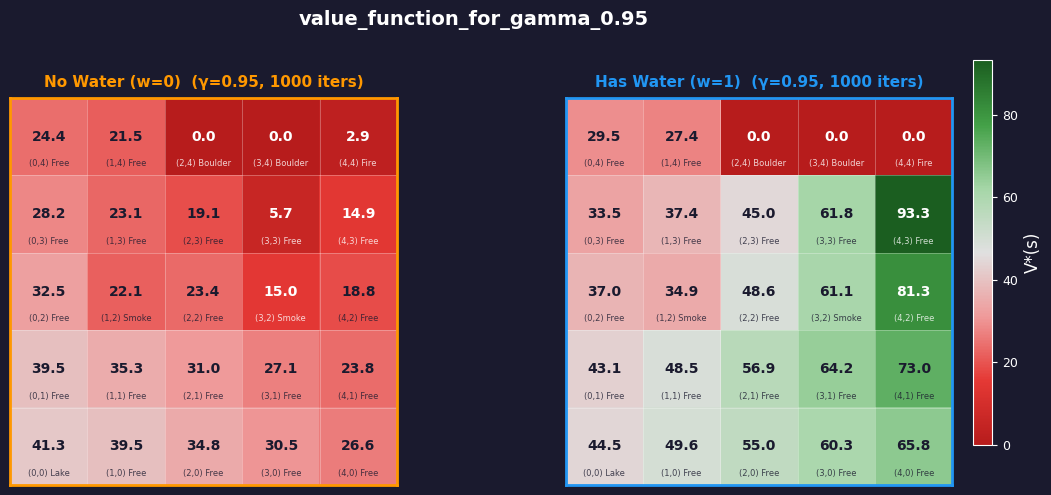

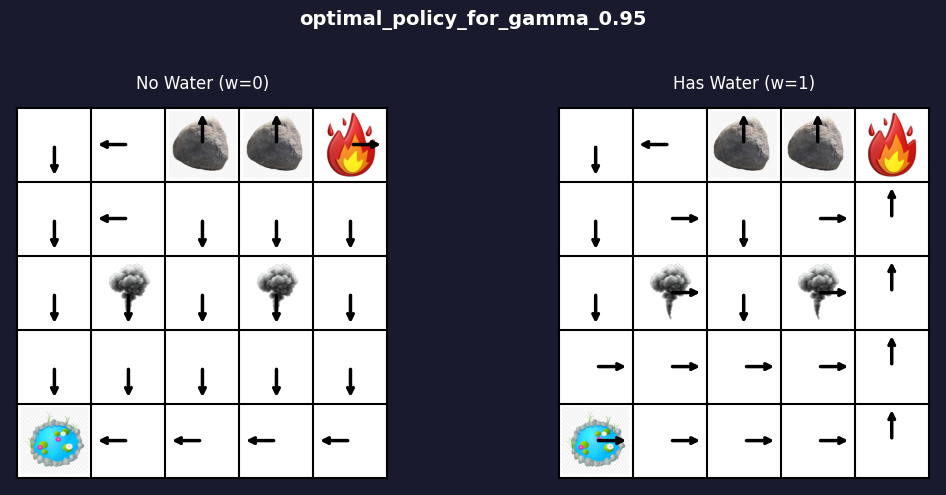

In [4]:
# Train the MDP
V1 = np.zeros(n_states)
for i in range(max_iter1):
    V1,converged = agent1.bellman_operator(P1,R1,V1)
    if converged:
        print("Number of iter = ",i)
        break

Q1 = agent1.compute_Q(P1,R1,V1)

fig_1_5 = visualize_value_function(V1, S1, "value_function_for_gamma_0.95", gamma1, max_iter1)
fig_1_6 = visualize_optimal_policy(Q1,S1,"optimal_policy_for_gamma_0.95")

plt.show()

### MDP by setting γ = 0.3

In [5]:
lake = (0, 0)
fire = (4, 4)
smoke_cells = {(1, 2), (3, 2)}
boulder_cells = {(2, 4), (3, 4)}
perp_actions = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}
n_states = 50
n_actions = 5
S2 = [""] * n_states
A2 = [(0, 1), (0, -1), (1, 0), (-1, 0), (0, 0)]
P2 = np.zeros((n_actions, n_states, n_states))
R2 = np.zeros((n_states, n_actions))
gamma2 = 0.3
max_iter2 = 1000

# State list S
for w in range(2):
    for y in range(5):
        for x in range(5):
            idx = x + 5 * y + 25 * w
            pos = (x, y)
            if pos == lake:       label = "Lake"
            elif pos == fire:     label = "Fire"
            elif pos in smoke_cells:   label = "Smoke"
            elif pos in boulder_cells: label = "Boulder"
            else:                 label = "Free"
            S2[idx] = f"{label}_{'Water' if w else 'Empty'}"

# Prob matrix (P)
for w in range(2):
    for y in range(5):
        for x in range(5):
            s = x + 5 * y + 25 * w
            if (x, y) in boulder_cells or ((x, y) == fire and w == 1):
                P2[:, s, s] = 1.0
                continue

            is_smoke = (x, y) in smoke_cells
            for a in range(n_actions):
                if a == 4: #Hovering
                    nw = 1 if (x, y) == lake and w == 0 else w
                    P2[a, s, x + 5 * y + 25 * nw] = 1.0
                    continue
                if is_smoke:
                    p_fwd, p_perp, p_stay = 0.4, 0.1, 0.4
                else:
                    p_fwd, p_perp, p_stay = 0.7, 0.1, 0.1

                dx, dy = A2[a]
                outcomes = [(dx, dy, p_fwd), (0, 0, p_stay)]
                for pa in perp_actions[a]:
                    pdx, pdy = A2[pa]
                    outcomes.append((pdx, pdy, p_perp))

                for mdx, mdy, prob in outcomes:
                    nx, ny = x + mdx, y + mdy
                    if not (0 <= nx < 5 and 0 <= ny < 5):
                        nx, ny = x, y  # off-grid: stay
                    nw = 1 if (nx, ny) == lake and w == 0 else w
                    P2[a, s, nx + 5 * ny + 25 * nw] += prob

# Reward Matrix (R)
for w in range(2):
    for y in range(5):
        for x in range(5):
            s = x + 5 * y + 25 * w
            if (x, y) in boulder_cells:
                for a in range(n_actions):
                    R2[s,a] = 0
                continue
            elif ((x, y) == fire and w == 1):
                for a in range(n_actions):
                    R2[s,a] = 0
                continue

            is_smoke = (x, y) in smoke_cells
            for a in range(n_actions):
                if a == 4: # hover: deterministic stay
                    R2[s, a] = -11.0 if is_smoke else -1.0
                    continue

                if is_smoke:
                    p_fwd, p_perp, p_stay = 0.4, 0.1, 0.4
                else:
                    p_fwd, p_perp, p_stay = 0.7, 0.1, 0.1

                dx, dy = A2[a]
                outcomes = [(dx, dy, p_fwd), (0, 0, p_stay)]
                for pa in perp_actions[a]:
                    pdx, pdy = A2[pa]
                    outcomes.append((pdx, pdy, p_perp))

                er = 0.0
                for mdx, mdy, prob in outcomes:
                    nx, ny = x + mdx, y + mdy
                    if not (0 <= nx < 5 and 0 <= ny < 5):
                        nx, ny = x, y
                    if (nx, ny) in boulder_cells:
                        er += prob * (-100.0)
                    elif (nx, ny) == fire and w == 1:
                        er += prob * 100.0
                    elif (nx, ny) in smoke_cells:
                        er += prob * (-11.0)
                    else:
                        er += prob * (-1.0)
                R2[s, a] = er

agent2 = Agent(S2, A2, P2, R2, gamma2)

####  3a Resulting optimal value function and policy(gamma = 0.3) and differnces [3M]

Number of iter =  21


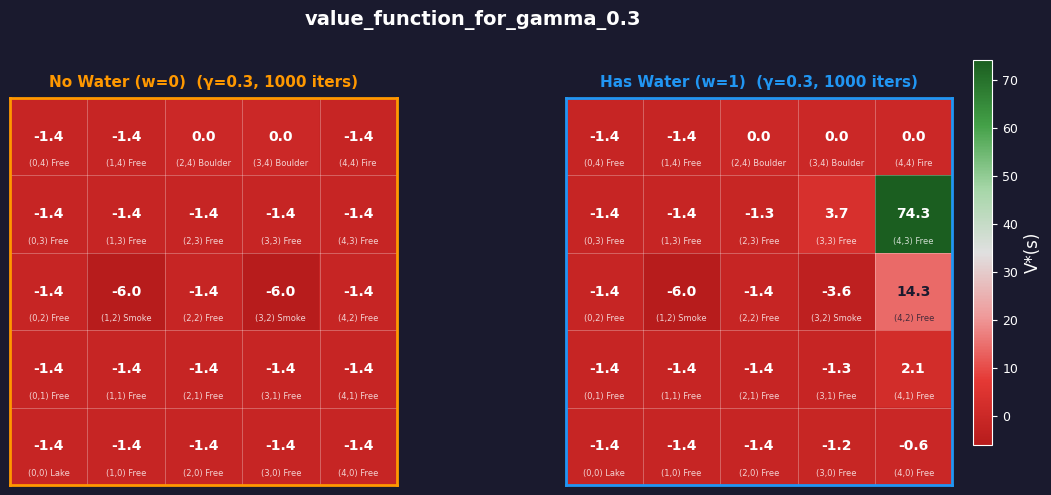

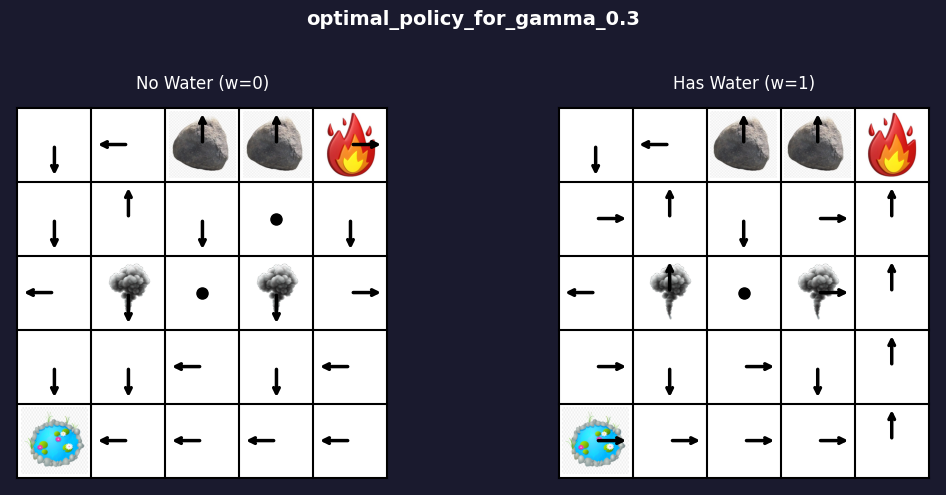

In [6]:
# Train the MDP
V2 = np.zeros(n_states)
for i in range(max_iter2):
    V2,converged = agent2.bellman_operator(P2,R2,V2)
    if converged:
        print("Number of iter = ",i)
        break

Q2 = agent2.compute_Q(P2,R2,V2)

fig_2_5 = visualize_value_function(V2, S2, "value_function_for_gamma_0.3", gamma2, max_iter2)
fig_2_6 = visualize_optimal_policy(Q2,S2,"optimal_policy_for_gamma_0.3")

plt.show()

#### 3a Analysis: Differences between γ=0.3 and γ=0.95

**Key differences:**
- **Magnitude:** Values much smaller with γ=0.3 due to heavy discounting
- **Awareness:** γ=0.95 is globally aware (plans 10+ steps ahead), γ=0.3 is myopic (only ~3-4 steps)

- **Risk-taking:** γ=0.95 takes calculated risks through hazards for distant rewards, γ=0.3 avoids any immediate dangerWith γ=0.3, distant rewards (8+ steps away) are discounted to near-zero: 0.3^8 ≈ 0.00066, making them negligible compared to immediate -1 step costs.

- **Behavior:** γ=0.3 shows hovering at hazard-surrounded cells, prefers safety over long-term gain

#### 3b What happens near the hazardous states when γ = 0.3? [2M]

The myopic agent at γ=0.3 cannot "see" past the immediate hazards to the eventual reward.

Near smoke cells {(1,2), (3,2)}, the value function is **lower** than surrounding cells in both γ=0.95 and γ=0.3 due to the -11 penalty.

- At **γ=0.3**: Values near hazards are **negative** (V < 0) because the agent is myopic — the +100 reward is discounted by 0.3^k (negligible for k>3), and only sees accumulated -1 step penalties and -11 smoke penalties

**Key difference:**- At **γ=0.95**: Values near hazards are still **positive** (V ≈ 20-40) because distant fire/lake rewards propagate strongly

#### 3c Cases where the drone prefers hovering despite the per-step penalty? [2M]
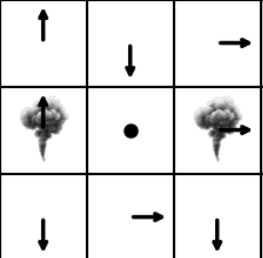

**YES**, the drone hovers at:

- **(2,2) with w∈{0,1}** — between the two smoke cellsThe drone prefers "doing nothing" over taking risky moves for negligible future gain. This behavior does NOT occur at γ=0.95 where V_hover = -20 << V_move.

- **(3,3) with w=0** — between the boulder cells

- Hovering (V_hover = -1/(1-0.3) ≈ -1.43) becomes the "least bad" option

**Reason:** With γ=0.3, the agent only looks ~3-4 steps ahead. When surrounded by hazards:- Distant reward is heavily discounted: 0.3^k × 100 ≈ 0 for k>5
- All neighboring moves incur immediate penalties (-11 smoke or risk of -100 boulder)

#### 3d Interesting states: Asymmetric smoke-cell values [2M]

Smoke cell **(3,2)** shows interesting asymmetry based on water level:

This demonstrates how **myopia at low γ collapses distant distinctions** — when goals are >5 steps away, all paths look equally bleak.
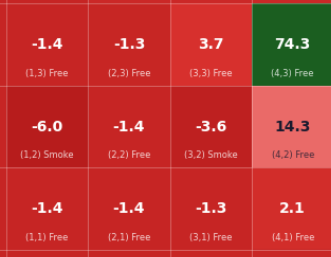

![image.png](attachment:image.png

| Water Level | Behavior |

|-------------|----------|

| **w=0** | Both smoke cells (1,2) and (3,2) have **equal** values |)

| **w=1** | Smoke (3,2) has **higher** value than (1,2) |

- **Without water (w=0):** Both smoke cells are ~12-14 steps from lake (0,0). Discount obliterates difference: 0.3¹² ≈ 5×10⁻⁷ and 0.3¹⁴ ≈ 5×10⁻⁸ — both effectively zero. Agent is "blind" to which is closer.

**Why this happens:**
- **With water (w=1):** Cell (3,2) is ~3 steps from fire (4,4), giving discounted reward 0.3³×100 ≈ 2.7 (significant). Cell (1,2) is farther (~5 steps), giving 0.3⁵×100 ≈ 0.24. Agent clearly "sees" (3,2) is closer.

### MDP by penalizing the drone more for entering hazardous states (penalty = −90). Keep γ = 0.95. [10M]

In [10]:
lake = (0, 0)
fire = (4, 4)
smoke_cells = {(1, 2), (3, 2)}
boulder_cells = {(2, 4), (3, 4)}
perp_actions = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}
n_states = 50
n_actions = 5
S3 = [""] * n_states
A3 = [(0, 1), (0, -1), (1, 0), (-1, 0), (0, 0)]
P3 = np.zeros((n_actions, n_states, n_states))
R3 = np.zeros((n_states, n_actions))
gamma3 = 0.9
max_iter3 = 1000

# State list S
for w in range(2):
    for y in range(5):
        for x in range(5):
            idx = x + 5 * y + 25 * w
            pos = (x, y)
            if pos == lake:       label = "Lake"
            elif pos == fire:     label = "Fire"
            elif pos in smoke_cells:   label = "Smoke"
            elif pos in boulder_cells: label = "Boulder"
            else:                 label = "Free"
            S3[idx] = f"{label}_{'Water' if w else 'Empty'}"

# Prob matrix (P)
for w in range(2):
    for y in range(5):
        for x in range(5):
            s = x + 5 * y + 25 * w
            if (x, y) in boulder_cells or ((x, y) == fire and w == 1):
                P3[:, s, s] = 1.0
                continue

            is_smoke = (x, y) in smoke_cells
            for a in range(n_actions):
                if a == 4: #Hovering
                    nw = 1 if (x, y) == lake and w == 0 else w
                    P3[a, s, x + 5 * y + 25 * nw] = 1.0
                    continue
                if is_smoke:
                    p_fwd, p_perp, p_stay = 0.4, 0.1, 0.4
                else:
                    p_fwd, p_perp, p_stay = 0.7, 0.1, 0.1

                dx, dy = A3[a]
                outcomes = [(dx, dy, p_fwd), (0, 0, p_stay)]
                for pa in perp_actions[a]:
                    pdx, pdy = A3[pa]
                    outcomes.append((pdx, pdy, p_perp))

                for mdx, mdy, prob in outcomes:
                    nx, ny = x + mdx, y + mdy
                    if not (0 <= nx < 5 and 0 <= ny < 5):
                        nx, ny = x, y  # off-grid: stay
                    nw = 1 if (nx, ny) == lake and w == 0 else w
                    P3[a, s, nx + 5 * ny + 25 * nw] += prob

# Reward Matrix (R)
for w in range(2):
    for y in range(5):
        for x in range(5):
            s = x + 5 * y + 25 * w
            if (x, y) in boulder_cells:
                for a in range(n_actions):
                    R3[s,a] = 0
                continue
            elif ((x, y) == fire and w == 1):
                for a in range(n_actions):
                    R3[s,a] = 0
                continue

            is_smoke = (x, y) in smoke_cells
            for a in range(n_actions):
                if a == 4: # hover: deterministic stay
                    R3[s, a] = -90.0 if is_smoke else -1.0
                    continue

                if is_smoke:
                    p_fwd, p_perp, p_stay = 0.4, 0.1, 0.4
                else:
                    p_fwd, p_perp, p_stay = 0.7, 0.1, 0.1

                dx, dy = A3[a]
                outcomes = [(dx, dy, p_fwd), (0, 0, p_stay)]
                for pa in perp_actions[a]:
                    pdx, pdy = A3[pa]
                    outcomes.append((pdx, pdy, p_perp))

                er = 0.0
                for mdx, mdy, prob in outcomes:
                    nx, ny = x + mdx, y + mdy
                    if not (0 <= nx < 5 and 0 <= ny < 5):
                        nx, ny = x, y
                    if (nx, ny) in boulder_cells:
                        er += prob * (-100.0)
                    elif (nx, ny) == fire and w == 1:
                        er += prob * 100.0
                    elif (nx, ny) in smoke_cells:
                        er += prob * (-90.0)
                    else:
                        er += prob * (-1.0)
                R3[s, a] = er

agent3 = Agent(S3, A3, P3, R3, gamma3)

#### 4a Optimal value function and policy with -90 hazard penalty [3M]

Number of iter =  219


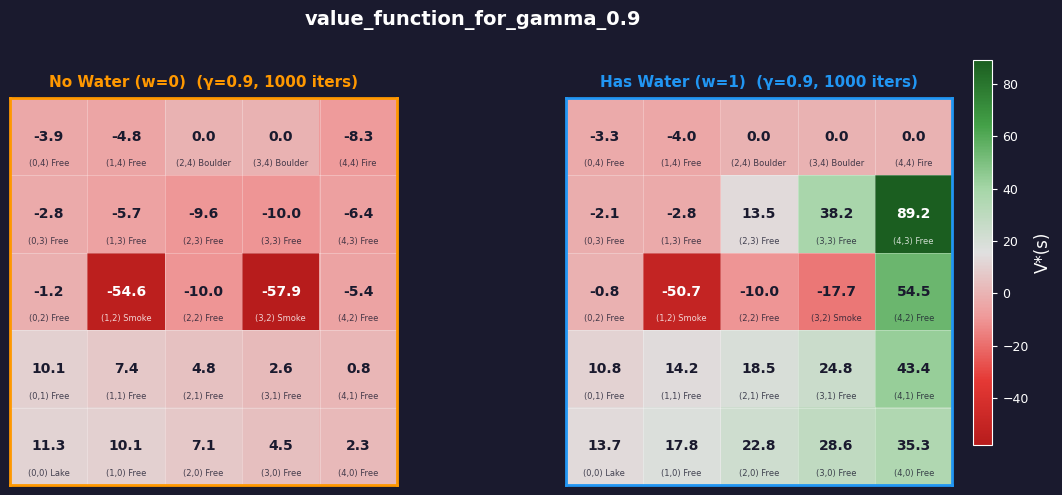

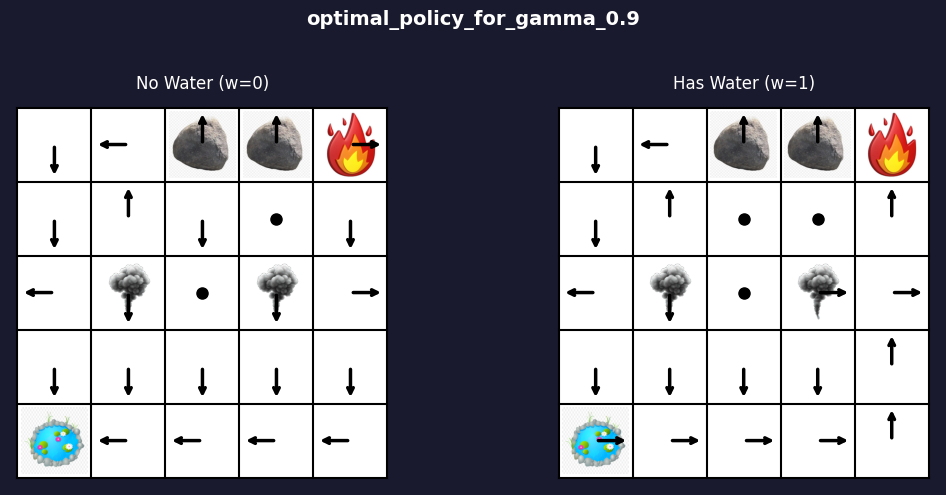

In [11]:
# Train the MDP
V3 = np.zeros(n_states)
for i in range(max_iter3):
    V3,converged = agent3.bellman_operator(P3,R3,V3)
    if converged:
        print("Number of iter = ",i)
        break

Q3 = agent2.compute_Q(P3,R3,V3)

fig_3_5 = visualize_value_function(V3, S3, "value_function_for_gamma_0.9", gamma3, max_iter3)
fig_3_6 = visualize_optimal_policy(Q3,S3,"optimal_policy_for_gamma_0.9")

plt.show()

#### 4a Analysis: Differences with γ=0.9 and -90 hazard penalty

Images: [value_function_for_gamma_0.9.png](images/value_function_for_gamma_0.9.png), [optimal_policy_for_gamma_0.9.png](images/optimal_policy_for_gamma_0.9.png)

**Smoke regions as negative convergence zones:**
- With -90 penalty, smoke cells nearly as bad as boulders (-100)
- Fear of getting stuck in smoke dominates the reward of reaching goal
- Regions near smoke show strongly negative values

**Key observations:**
1. **Cell (4,2)**: Just 2 steps from fire (4,4), but policy shows avoidance — fears 10% drift into smoke (3,2)
2. **Slower convergence**: Took more iterations than γ=0.95 or γ=0.3. Hypothesis: at γ=0.9, balance between immediate penalties and discounted rewards creates numerical instability — neither short-term nor long-term dominates
3. **Value magnitudes**: All values between γ=0.95 (high) and γ=0.3 (low)

**Discount factor interpretation:**
- γ=0.3 → 1/(1-0.3) ≈ 1.4 steps (short-term)
- γ=0.9 → 1/(1-0.9) = 10 steps (medium-term)
- γ=0.95 → 1/(1-0.95) = 20 steps (long-term)
- γ=0.99 → 1/(1-0.99) = 100 steps (very long-term, for complex tasks)

#### 4b Hovering scenarios — The "Indecision Threshold" [2M]

**YES**, and surprisingly γ=0.9 has the **MOST hovering states** — 5 out of 50:
- (3,3) with w∈{0,1} — between boulders
- (4,3) with w∈{0,1} — adjacent to fire and boulders  
- (1,3) with w=0 — near smoke cells

**The Indecision Threshold Phenomena:**

**At γ=0.3 (shortsighted):** Only next 1-2 steps matter. Best action is obvious because distant futures barely exist. **Result:** Fast convergence, stable policy, minimal hovering.

**At γ=0.95 (farsighted):** Values 20+ steps ahead. Current reward and distant future align into clear long-term strategy. **Result:** Smooth value gradients, coherent policy, minimal hovering.

**At γ=0.9 (indecision threshold):** Immediate rewards and discounted future rewards have nearly **equal weight**. Creates ambiguity: quick win vs. long-term gain yield similar Q-values. Bellman equation "wavers" between competing actions, never committing strongly. **Result:** Maximum hovering where multiple actions appear equally (sub)optimal.

This explains why γ=0.9 paradoxically has MORE hovering than myopic γ=0.3 — it's not about being shortsighted, but being caught between two timescales!

#### 4c Longer path preference — Safety over efficiency [2M]

**YES**, example at smoke cell (1,2):

![Preferred long path](images/prefered_long_path.jpeg)

The optimal policy takes a **long detour** to avoid smoke and boulders, even attempting off-grid moves (which bounce back) to minimize risk.

**Why the long path wins?**

**Short path** from (1,2) to fire (4,4): Passes through high-risk regions with 2 boulders {(2,4), (3,4)} and smoke (3,2) in close proximity. With stochastic wind (40% forward, 10% perpendicular, 40% stay), cumulative probability of hitting hazard is unacceptably high.

**Long path**: Takes wide detour, even intentionally moving **off-grid** (bounces back, wastes a step) to reset position. Agent reasons: "10% chance of drifting toward fire (via perpendicular wind off-grid) is safer than 10% chance of drifting into -90 smoke or -100 boulder."

The drone is willing to **waste many steps** (at -1 each) rather than risk entering smoke. With -90 penalty, smoke is nearly as punishing as terminal death, making avoidance worth the cost.

**Key insight:** With severe hazard penalties, risk-adjusted expected return of long, safe path exceeds short, dangerous path — classic exploration-exploitation trade-off favoring safety.

#### 4d
Given the above MDP with the −90 hazard penalty and γ = 0.95, suppose the
wind becomes stronger. As a result, in all non-terminal states, the drone moves
in the intended direction with a chance of 40%, in either of the perpendicular
direction with a chance of 25%, and stays in same the cell rest of the times.
Comment your thoughts on the solution to the resulting MDP. [3M]

In [12]:
# Stronger wind: forward 40%, perpendicular 25% each, stay 10%

lake = (0, 0)
fire = (4, 4)
smoke_cells = {(1, 2), (3, 2)}
boulder_cells = {(2, 4), (3, 4)}
perp_actions = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}
n_states = 50
n_actions = 5
S4 = [""] * n_states
A4 = [(0, 1), (0, -1), (1, 0), (-1, 0), (0, 0)]
P4 = np.zeros((n_actions, n_states, n_states))
R4 = np.zeros((n_states, n_actions))
gamma4 = 0.95
max_iter4 = 1000

# State list S
for w in range(2):
    for y in range(5):
        for x in range(5):
            idx = x + 5 * y + 25 * w
            pos = (x, y)
            if pos == lake:       label = "Lake"
            elif pos == fire:     label = "Fire"
            elif pos in smoke_cells:   label = "Smoke"
            elif pos in boulder_cells: label = "Boulder"
            else:                 label = "Free"
            S4[idx] = f"{label}_{'Water' if w else 'Empty'}"

# Prob matrix (P) - STRONGER WIND
for w in range(2):
    for y in range(5):
        for x in range(5):
            s = x + 5 * y + 25 * w
            if (x, y) in boulder_cells or ((x, y) == fire and w == 1):
                P4[:, s, s] = 1.0
                continue

            for a in range(n_actions):
                if a == 4: #Hovering
                    nw = 1 if (x, y) == lake and w == 0 else w
                    P4[a, s, x + 5 * y + 25 * nw] = 1.0
                    continue
                
                # Stronger wind: 40% forward, 25% each perpendicular, 10% stay
                p_fwd, p_perp, p_stay = 0.4, 0.25, 0.1

                dx, dy = A4[a]
                outcomes = [(dx, dy, p_fwd), (0, 0, p_stay)]
                for pa in perp_actions[a]:
                    pdx, pdy = A4[pa]
                    outcomes.append((pdx, pdy, p_perp))

                for mdx, mdy, prob in outcomes:
                    nx, ny = x + mdx, y + mdy
                    if not (0 <= nx < 5 and 0 <= ny < 5):
                        nx, ny = x, y  # off-grid: stay
                    nw = 1 if (nx, ny) == lake and w == 0 else w
                    P4[a, s, nx + 5 * ny + 25 * nw] += prob

# Reward Matrix (R) - with -90 smoke penalty
for w in range(2):
    for y in range(5):
        for x in range(5):
            s = x + 5 * y + 25 * w
            if (x, y) in boulder_cells:
                for a in range(n_actions):
                    R4[s,a] = 0
                continue
            elif ((x, y) == fire and w == 1):
                for a in range(n_actions):
                    R4[s,a] = 0
                continue

            is_smoke = (x, y) in smoke_cells
            for a in range(n_actions):
                if a == 4: # hover: deterministic stay
                    R4[s, a] = -90.0 if is_smoke else -1.0
                    continue

                # Stronger wind probabilities for reward calculation
                p_fwd, p_perp, p_stay = 0.4, 0.25, 0.1

                dx, dy = A4[a]
                outcomes = [(dx, dy, p_fwd), (0, 0, p_stay)]
                for pa in perp_actions[a]:
                    pdx, pdy = A4[pa]
                    outcomes.append((pdx, pdy, p_perp))

                er = 0.0
                for mdx, mdy, prob in outcomes:
                    nx, ny = x + mdx, y + mdy
                    if not (0 <= nx < 5 and 0 <= ny < 5):
                        nx, ny = x, y
                    if (nx, ny) in boulder_cells:
                        er += prob * (-100.0)
                    elif (nx, ny) == fire and w == 1:
                        er += prob * 100.0
                    elif (nx, ny) in smoke_cells:
                        er += prob * (-90.0)
                    else:
                        er += prob * (-1.0)
                R4[s, a] = er

agent4 = Agent(S4, A4, P4, R4, gamma4)

#### 4d Analysis: Stronger wind results

Number of iter =  449


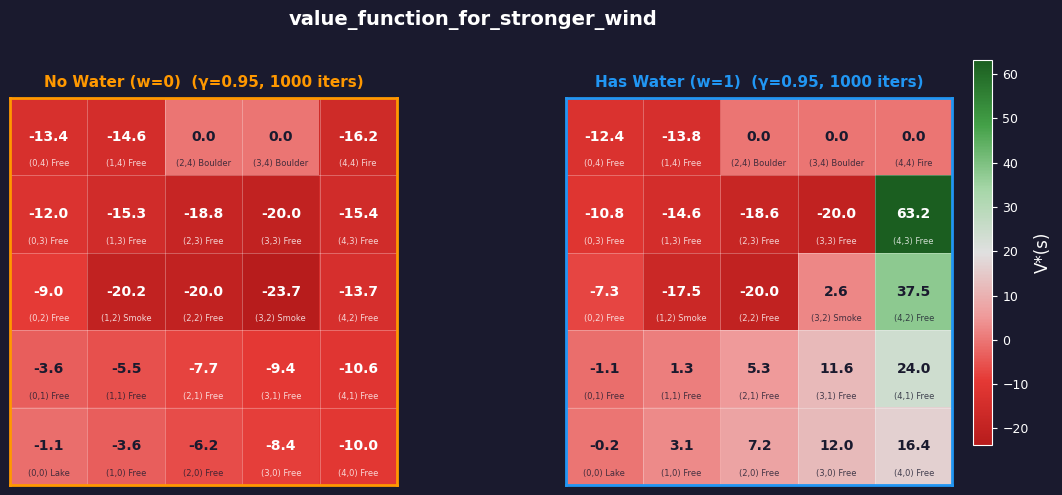

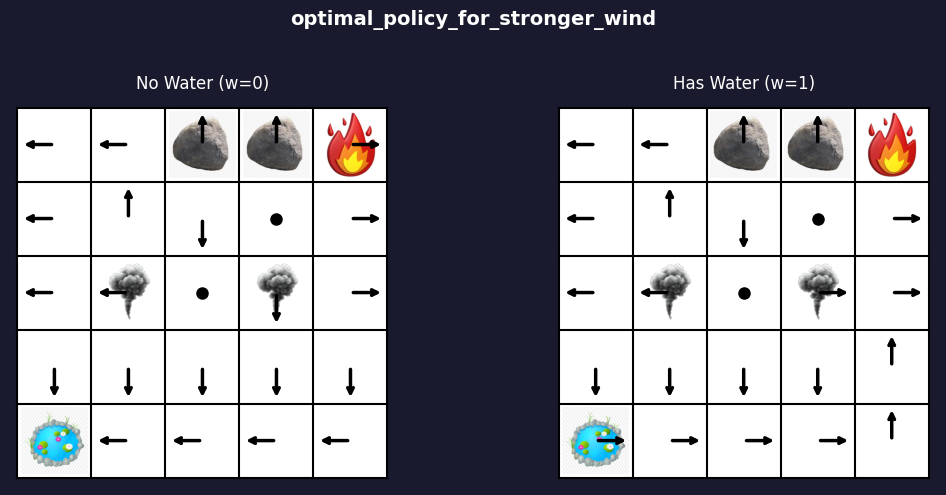

In [13]:
# Train the MDP with stronger wind
V4 = np.zeros(n_states)
for i in range(max_iter4):
    V4,converged = agent4.bellman_operator(P4,R4,V4)
    if converged:
        print("Number of iter = ",i)
        break

Q4 = agent4.compute_Q(P4,R4,V4)

fig_4_5 = visualize_value_function(V4, S4, "value_function_for_stronger_wind", gamma4, max_iter4)
fig_4_6 = visualize_optimal_policy(Q4,S4,"optimal_policy_for_stronger_wind")

plt.show()

#### 4d Observations and Analysis:

**Changes with stronger wind (40% forward, 25% perpendicular each, 10% stay):**

1. **Increased stochasticity**: Perpendicular drift probability increased from 10% to 25% (2.5× higher), making movement much less predictable

2. **Higher expected hazard risk**: With 50% total perpendicular drift (25%+25%), navigating near smoke/boulders becomes significantly riskier

3. **Lower value functions**: Expected cumulative rewards have decreased across all states due to higher chance of unintended hazard encounters

4. **More conservative policy**: Agent likely prefers:
   - Wider safety margins around hazards
   - More hovering in ambiguous locations
   - Longer detour paths to avoid risk corridors

5. **Convergence**: Took more iterations due to increased uncertainty in Bellman updates

**Key comparison**: Original wind (70%/10%/10%) vs Stronger wind (40%/25%/25%):
- Control degradation: Forward probability drops from 70% to 40% (↓43%)
- Drift amplification: Perpendicular risk rises from 20% total to 50% total (↑150%)
- This combination makes navigation near smoke cells (with their already chaotic 40%/40%/10% dynamics) extremely hazardous

Images: [value_function_for_stronger_wind.png](images/value_function_for_stronger_wind.png), [optimal_policy_for_stronger_wind.png](images/optimal_policy_for_stronger_wind.png)